# 🎬 Movie Recommendation System — Complete Master Notebook
> **Type:** Content-Based Filtering | **Algorithm:** Cosine Similarity | **Platform:** Google Colab

---
## 📋 Table of Contents

| Part | Steps | What It Covers |
|------|-------|----------------|
| Part 1 — Setup | 1–2 | Install libraries, imports |
| Part 2 — Load Data | 3–5 | Load CSVs, explore, check quality |
| Part 3 — Preprocessing | 6–11 | Clean, merge, build features |
| Part 4 — Vectorization | 12–14 | TF-IDF, CountVectorizer, vectors |
| Part 5 — Similarity | 15–16 | Cosine similarity matrix |
| Part 6 — Engine | 17–18 | Recommendation function, test |
| Part 7 — Fine-Tuning | 19–22 | Accuracy, weight tuning, evaluation |
| Part 8 — Save & Export | 23–24 | Save PKL files, final summary |

---
## 🗂️ Project Flow
```
movies.csv + ratings.csv
        ↓
  Data Cleaning & Merging
        ↓
  Feature Engineering (tags)
        ↓
  TF-IDF Vectorization
        ↓
  Cosine Similarity Matrix
        ↓
  Recommendation Function
        ↓
  Fine-Tuning & Evaluation
        ↓
  Save movies.pkl + similarity.pkl
        ↓
  Streamlit Web App
```

---
> ⚠️ **Run every cell top to bottom using Shift+Enter. Do NOT skip any cell.**

---
# 🔧 PART 1 — SETUP
---

## ✅ STEP 1 — Install Required Libraries
Run this first. Installs everything before any imports.

| Library | Purpose |
|---------|--------|
| pandas | Data loading and manipulation |
| numpy | Numerical operations |
| scikit-learn | Vectorization + cosine similarity |
| pickle | Save/load model files |
| matplotlib | Visualize data distributions |
| seaborn | Heatmaps and plots |

In [1]:
# ============================================================
#  Install all dependencies — prevents ModuleNotFoundError
#  Run this cell first before anything else
# ============================================================
import subprocess, sys

packages = ['pandas', 'numpy', 'scikit-learn', 'matplotlib', 'seaborn']
for pkg in packages:
    subprocess.check_call([sys.executable, '-m', 'pip', 'install', pkg, '--quiet'])
    print(f'  ✅ {pkg} installed')

print('\n🎉 All libraries installed successfully!')

  ✅ pandas installed
  ✅ numpy installed
  ✅ scikit-learn installed
  ✅ matplotlib installed
  ✅ seaborn installed

🎉 All libraries installed successfully!


## ✅ STEP 2 — Import All Libraries
Imports every module used across the entire notebook.

In [2]:
# ============================================================
#  Core imports — all used later in this notebook
# ============================================================
import pandas as pd                                        # Data manipulation
import numpy as np                                         # Numerical arrays
import pickle                                              # Save/load model files
import re                                                  # Text cleaning
import warnings
warnings.filterwarnings('ignore')

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
from sklearn.preprocessing import MinMaxScaler

# Display settings
pd.set_option('display.max_columns', 20)
pd.set_option('display.max_colwidth', 60)

print('✅ All libraries imported successfully!')
print('✅ pandas version :', pd.__version__)
print('✅ numpy  version :', np.__version__)

✅ All libraries imported successfully!
✅ pandas version : 2.3.3
✅ numpy  version : 1.26.4


---
# 📂 PART 2 — LOAD & EXPLORE DATA
---

## ✅ STEP 3 — Load the Dataset
We use the **MovieLens dataset** which contains:
- `movies.csv` — movieId, title, genres
- `ratings.csv` — userId, movieId, rating, timestamp

> 📥 **Download dataset:** https://grouplens.org/datasets/movielens/latest/
> Download `ml-latest-small.zip`, unzip it, and place `movies.csv` + `ratings.csv` in a folder called `dataset/`

In [3]:
# ============================================================
#  STEP 3 — Load both CSV files
#  FIX: Added error handling so the notebook tells you clearly
#  if the files are missing instead of crashing silently
# ============================================================

import os

# Auto-detect dataset location (works in Colab and local)
DATASET_PATH = 'dataset'

# If dataset folder doesn't exist, try downloading automatically in Colab
if not os.path.exists(DATASET_PATH):
    print('Dataset folder not found. Attempting auto-download...')
    try:
        import urllib.request, zipfile
        url = 'https://files.grouplens.org/datasets/movielens/ml-latest-small.zip'
        print('Downloading MovieLens dataset...')
        urllib.request.urlretrieve(url, 'ml-latest-small.zip')
        with zipfile.ZipFile('ml-latest-small.zip', 'r') as z:
            z.extractall('.')
        os.rename('ml-latest-small', DATASET_PATH)
        print('✅ Dataset downloaded and extracted to dataset/ folder!')
    except Exception as e:
        print('Auto-download failed:', str(e))
        print('Please manually upload movies.csv and ratings.csv to dataset/ folder.')

# Load the files
try:
    movies  = pd.read_csv(os.path.join(DATASET_PATH, 'movies.csv'))
    ratings = pd.read_csv(os.path.join(DATASET_PATH, 'ratings.csv'))
    print('✅ movies.csv  loaded:', movies.shape[0], 'rows,', movies.shape[1], 'columns')
    print('✅ ratings.csv loaded:', ratings.shape[0], 'rows,', ratings.shape[1], 'columns')
except FileNotFoundError as e:
    print('❌ File not found:', str(e))
    print('Please place movies.csv and ratings.csv inside a folder named dataset/')

Dataset folder not found. Attempting auto-download...
✅ Dataset downloaded and extracted to dataset/ folder!
✅ movies.csv  loaded: 9742 rows, 3 columns
✅ ratings.csv loaded: 100836 rows, 4 columns


## ✅ STEP 4 — Explore the Dataset
Always look at your data before touching it. This tells us:
- What columns exist
- What the data looks like
- What needs to be cleaned

In [4]:
# ============================================================
#  STEP 4 — Full dataset exploration
# ============================================================

print('=' * 55)
print('MOVIES.CSV — First 5 rows')
print('=' * 55)
print(movies.head())

print('\n' + '=' * 55)
print('RATINGS.CSV — First 5 rows')
print('=' * 55)
print(ratings.head())

print('\n' + '=' * 55)
print('MOVIES — Column Info')
print('=' * 55)
print(movies.dtypes)

print('\n' + '=' * 55)
print('RATINGS — Column Info')
print('=' * 55)
print(ratings.dtypes)

print('\n' + '=' * 55)
print('BASIC STATISTICS')
print('=' * 55)
print('Total movies        :', movies.shape[0])
print('Total ratings       :', ratings.shape[0])
print('Unique users        :', ratings['userId'].nunique())
print('Unique movies rated :', ratings['movieId'].nunique())
print('Rating range        :', ratings['rating'].min(), '—', ratings['rating'].max())
print('Average rating      :', round(ratings['rating'].mean(), 2))

MOVIES.CSV — First 5 rows
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  

RATINGS.CSV — First 5 rows
   userId  movieId  rating  timestamp
0       1        1     4.0  964982703
1       1        3     4.0  964981247
2       1        6     4.0  964982224
3       1       47     5.0  964983815
4       1       50     5.0  964982931

MOVIES — Column Info
movieId     int64
title      object
genres     object
dtype: object

RATINGS — Column Info
userId    

## ✅ STEP 5 — Check Data Quality (Missing Values & Duplicates)
We must find and fix:
- Missing values (NaN)
- Duplicate rows
- Bad genre labels like `(no genres listed)`

In [5]:
# ============================================================
#  STEP 5 — Data quality checks
# ============================================================

print('MISSING VALUES — movies.csv')
print(movies.isnull().sum())

print('\nMISSING VALUES — ratings.csv')
print(ratings.isnull().sum())

print('\nDUPLICATE ROWS — movies.csv  :', movies.duplicated().sum())
print('DUPLICATE ROWS — ratings.csv :', ratings.duplicated().sum())

# Check for movies with no genre
no_genre = movies[movies['genres'] == '(no genres listed)']
print('\nMovies with NO genre listed  :', len(no_genre))

# Rating distribution
print('\nRATING DISTRIBUTION:')
print(ratings['rating'].value_counts().sort_index())

# Genre distribution
print('\nTOP 10 GENRES (by frequency):')
all_genres = movies['genres'].str.split('|').explode()
print(all_genres.value_counts().head(10))

MISSING VALUES — movies.csv
movieId    0
title      0
genres     0
dtype: int64

MISSING VALUES — ratings.csv
userId       0
movieId      0
rating       0
timestamp    0
dtype: int64

DUPLICATE ROWS — movies.csv  : 0
DUPLICATE ROWS — ratings.csv : 0

Movies with NO genre listed  : 34

RATING DISTRIBUTION:
rating
0.5     1370
1.0     2811
1.5     1791
2.0     7551
2.5     5550
3.0    20047
3.5    13136
4.0    26818
4.5     8551
5.0    13211
Name: count, dtype: int64

TOP 10 GENRES (by frequency):
genres
Drama        4361
Comedy       3756
Thriller     1894
Action       1828
Romance      1596
Adventure    1263
Crime        1199
Sci-Fi        980
Horror        978
Fantasy       779
Name: count, dtype: int64


---
# 🧹 PART 3 — DATA PREPROCESSING
---

## ✅ STEP 6 — Clean the Movies Dataset
Remove bad rows and keep only the columns we need.

In [6]:
# ============================================================
#  STEP 6 — Clean movies dataframe
# ============================================================

# Keep only needed columns
movies = movies[['movieId', 'title', 'genres']].copy()

# Drop rows with missing values
movies.dropna(inplace=True)

# Drop duplicate rows
movies.drop_duplicates(inplace=True)

# FIX: Remove movies with no genres listed — they add noise
movies = movies[movies['genres'] != '(no genres listed)']

# Reset index cleanly after filtering
movies.reset_index(drop=True, inplace=True)

print('✅ movies cleaned')
print('   Shape:', movies.shape)
print(movies.head())

✅ movies cleaned
   Shape: (9708, 3)
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  
0  Adventure|Animation|Children|Comedy|Fantasy  
1                   Adventure|Children|Fantasy  
2                               Comedy|Romance  
3                         Comedy|Drama|Romance  
4                                       Comedy  


## ✅ STEP 7 — Clean the Ratings Dataset
Filter ratings to keep only meaningful ones (rating >= 3.0 means the user liked it).

In [7]:
# ============================================================
#  STEP 7 — Clean ratings dataframe
# ============================================================

# Drop the timestamp column — not needed for recommendations
ratings = ratings[['userId', 'movieId', 'rating']].copy()

# Drop missing and duplicate rows
ratings.dropna(inplace=True)
ratings.drop_duplicates(inplace=True)

# FIX: Keep only ratings >= 3.0 (user liked the movie)
# Low ratings add noise to the popularity score
ratings = ratings[ratings['rating'] >= 3.0]

# Calculate average rating per movie (used in fine-tuning)
avg_ratings = ratings.groupby('movieId').agg(
    avg_rating  = ('rating', 'mean'),
    rating_count = ('rating', 'count')
).reset_index()

print('✅ ratings cleaned')
print('   Shape:', ratings.shape)
print('\nAverage rating per movie (sample):')
print(avg_ratings.head())

✅ ratings cleaned
   Shape: (81763, 3)

Average rating per movie (sample):
   movieId  avg_rating  rating_count
0        1    4.065327           199
1        2    3.741573            89
2        3    3.616279            43
3        4    3.000000             4
4        5    3.421053            38


## ✅ STEP 8 — Merge Movies with Rating Statistics
Combine the movies data with average rating and rating count.
This lets us boost popular, well-rated movies in recommendations.

In [8]:
# ============================================================
#  STEP 8 — Merge movies + rating stats
# ============================================================

# Left join: keep all movies, add rating stats where available
movies = movies.merge(avg_ratings, on='movieId', how='left')

# Fill missing rating stats with neutral values
movies['avg_rating'].fillna(movies['avg_rating'].median(), inplace=True)
movies['rating_count'].fillna(0, inplace=True)

# Round avg_rating for readability
movies['avg_rating'] = movies['avg_rating'].round(2)
movies['rating_count'] = movies['rating_count'].astype(int)

print('✅ Merged dataset created')
print('   Shape:', movies.shape)
print('\nSample:')
print(movies.head())

✅ Merged dataset created
   Shape: (9708, 5)

Sample:
   movieId                               title  \
0        1                    Toy Story (1995)   
1        2                      Jumanji (1995)   
2        3             Grumpier Old Men (1995)   
3        4            Waiting to Exhale (1995)   
4        5  Father of the Bride Part II (1995)   

                                        genres  avg_rating  rating_count  
0  Adventure|Animation|Children|Comedy|Fantasy        4.07           199  
1                   Adventure|Children|Fantasy        3.74            89  
2                               Comedy|Romance        3.62            43  
3                         Comedy|Drama|Romance        3.00             4  
4                                       Comedy        3.42            38  


## ✅ STEP 9 — Extract Year from Title
Movie titles contain the year like `Toy Story (1995)`.
We extract it as a separate feature — useful for filtering by decade.

In [9]:
# ============================================================
#  STEP 9 — Extract year from title
# ============================================================

def extract_year(title):
    """Extract the 4-digit year from a movie title string."""
    match = re.search(r'\((\d{4})\)', str(title))
    return int(match.group(1)) if match else 0

def clean_title(title):
    """Remove the year and extra spaces from the title."""
    return re.sub(r'\(\d{4}\)', '', str(title)).strip()


movies['year']         = movies['title'].apply(extract_year)
movies['clean_title']  = movies['title'].apply(clean_title)

print('✅ Year and clean title extracted')
print(movies[['title', 'clean_title', 'year']].head(8))

✅ Year and clean title extracted
                                title                  clean_title  year
0                    Toy Story (1995)                    Toy Story  1995
1                      Jumanji (1995)                      Jumanji  1995
2             Grumpier Old Men (1995)             Grumpier Old Men  1995
3            Waiting to Exhale (1995)            Waiting to Exhale  1995
4  Father of the Bride Part II (1995)  Father of the Bride Part II  1995
5                         Heat (1995)                         Heat  1995
6                      Sabrina (1995)                      Sabrina  1995
7                 Tom and Huck (1995)                 Tom and Huck  1995


## ✅ STEP 10 — Process Genres into Clean Text
Convert `Action|Adventure|Sci-Fi` → `Action Adventure SciFi`

The vectorizer needs plain space-separated words — not pipe-separated strings.

In [10]:
# ============================================================
#  STEP 10 — Clean and format genres for vectorization
# ============================================================

def clean_genres(genres_str):
    """
    Convert pipe-separated genre string to space-separated.
    Also removes hyphens (Sci-Fi → SciFi) so it's one token.
    Example: 'Action|Sci-Fi|Adventure' → 'Action SciFi Adventure'
    """
    genres = str(genres_str).replace('|', ' ')
    genres = genres.replace('-', '')      # Sci-Fi → SciFi
    genres = genres.replace(' ', ' ')     # normalize spaces
    return genres.strip()


movies['genres_clean'] = movies['genres'].apply(clean_genres)

print('✅ Genres cleaned')
print('\nBefore vs After:')
print('{:<35} {}'.format('Original', 'Cleaned'))
print('-' * 70)
for _, row in movies[['genres', 'genres_clean']].head(6).iterrows():
    print('{:<35} {}'.format(row['genres'], row['genres_clean']))

✅ Genres cleaned

Before vs After:
Original                            Cleaned
----------------------------------------------------------------------
Adventure|Animation|Children|Comedy|Fantasy Adventure Animation Children Comedy Fantasy
Adventure|Children|Fantasy          Adventure Children Fantasy
Comedy|Romance                      Comedy Romance
Comedy|Drama|Romance                Comedy Drama Romance
Comedy                              Comedy
Action|Crime|Thriller               Action Crime Thriller


## ✅ STEP 11 — Build the Tags Feature (Main Feature for Recommendations)
`tags` = the single text field the model uses to find similar movies.

We combine genre (repeated for weight) + year decade for richer signal.

In [11]:
# ============================================================
#  STEP 11 — Build the tags feature
#  FIX: Genres repeated 3x to give them more weight in vectors
#  FIX: Decade added as a soft time-period signal
# ============================================================

def get_decade(year):
    """Convert a year to its decade string e.g. 1995 → decade1990"""
    if year == 0:
        return ''
    decade = (year // 10) * 10
    return 'decade' + str(decade)


movies['decade'] = movies['year'].apply(get_decade)

# Build tags: genre (x3 for weight) + decade
# Repeating genres increases their TF-IDF importance
movies['tags'] = (
    movies['genres_clean'] + ' ' +
    movies['genres_clean'] + ' ' +
    movies['genres_clean'] + ' ' +
    movies['decade']
).str.strip()

# Convert to lowercase for consistent vectorization
movies['tags'] = movies['tags'].str.lower()

print('✅ Tags feature built')
print('\nSample tags:')
print(movies[['title', 'tags']].head(6).to_string())

✅ Tags feature built

Sample tags:
                                title                                                                                                                                            tags
0                    Toy Story (1995)  adventure animation children comedy fantasy adventure animation children comedy fantasy adventure animation children comedy fantasy decade1990
1                      Jumanji (1995)                                                     adventure children fantasy adventure children fantasy adventure children fantasy decade1990
2             Grumpier Old Men (1995)                                                                                         comedy romance comedy romance comedy romance decade1990
3            Waiting to Exhale (1995)                                                                       comedy drama romance comedy drama romance comedy drama romance decade1990
4  Father of the Bride Part II (1995)                  

---
# 🔢 PART 4 — VECTORIZATION
---

## ✅ STEP 12 — What Is Vectorization?
The computer cannot compare words directly. We convert text to numbers.

```
"Action Adventure"  →  [0, 1, 0, 1, 1, 0, 0]
"Comedy Romance"    →  [1, 0, 1, 0, 0, 1, 0]
```

We use **TF-IDF** (Term Frequency-Inverse Document Frequency) which is better than simple CountVectorizer because it down-weights common genres and boosts rare ones.

In [12]:
# ============================================================
#  STEP 12 — Compare CountVectorizer vs TF-IDF
#  We use TF-IDF for better accuracy (fine-tuning choice)
# ============================================================

# OPTION A: CountVectorizer — simple word counts
cv = CountVectorizer(max_features=5000, stop_words='english')
cv_vectors = cv.fit_transform(movies['tags']).toarray()

# OPTION B: TF-IDF — smarter weighting (used in final model)
tfidf = TfidfVectorizer(max_features=5000, stop_words='english')
tfidf_vectors = tfidf.fit_transform(movies['tags']).toarray()

print('CountVectorizer vector shape :', cv_vectors.shape)
print('TF-IDF vector shape          :', tfidf_vectors.shape)
print('\nVocabulary size (unique words):', len(tfidf.vocabulary_))
print('\nSample feature names:')
print(list(tfidf.vocabulary_.keys())[:20])
print('\n✅ We will use TF-IDF for better recommendation accuracy.')

CountVectorizer vector shape : (9708, 31)
TF-IDF vector shape          : (9708, 31)

Vocabulary size (unique words): 31

Sample feature names:
['adventure', 'animation', 'children', 'comedy', 'fantasy', 'decade1990', 'romance', 'drama', 'action', 'crime', 'thriller', 'horror', 'mystery', 'scifi', 'war', 'musical', 'documentary', 'decade1970', 'imax', 'decade1960']

✅ We will use TF-IDF for better recommendation accuracy.


## ✅ STEP 13 — Create Final Vectors
Using TF-IDF as our final vectorizer — better at handling common/rare genres.

In [13]:
# ============================================================
#  STEP 13 — Create final vectors using TF-IDF
# ============================================================

# Final vectorizer with tuned parameters
final_vectorizer = TfidfVectorizer(
    max_features = 5000,       # Limit vocabulary size
    stop_words   = 'english',  # Remove common English words
    ngram_range  = (1, 2),     # Include single words AND word pairs
    min_df       = 1,          # Include even rare genres
    sublinear_tf = True        # Scale term frequency logarithmically
)

vectors = final_vectorizer.fit_transform(movies['tags']).toarray()

print('✅ Final TF-IDF vectors created')
print('   Vector shape      :', vectors.shape)
print('   Movies            :', vectors.shape[0])
print('   Features (words)  :', vectors.shape[1])
print('\nEach movie is now represented as a vector of', vectors.shape[1], 'numbers.')

✅ Final TF-IDF vectors created
   Vector shape      : (9708, 505)
   Movies            : 9708
   Features (words)  : 505

Each movie is now represented as a vector of 505 numbers.


## ✅ STEP 14 — Visualize the Vector Space
See how genres are distributed across the vocabulary.

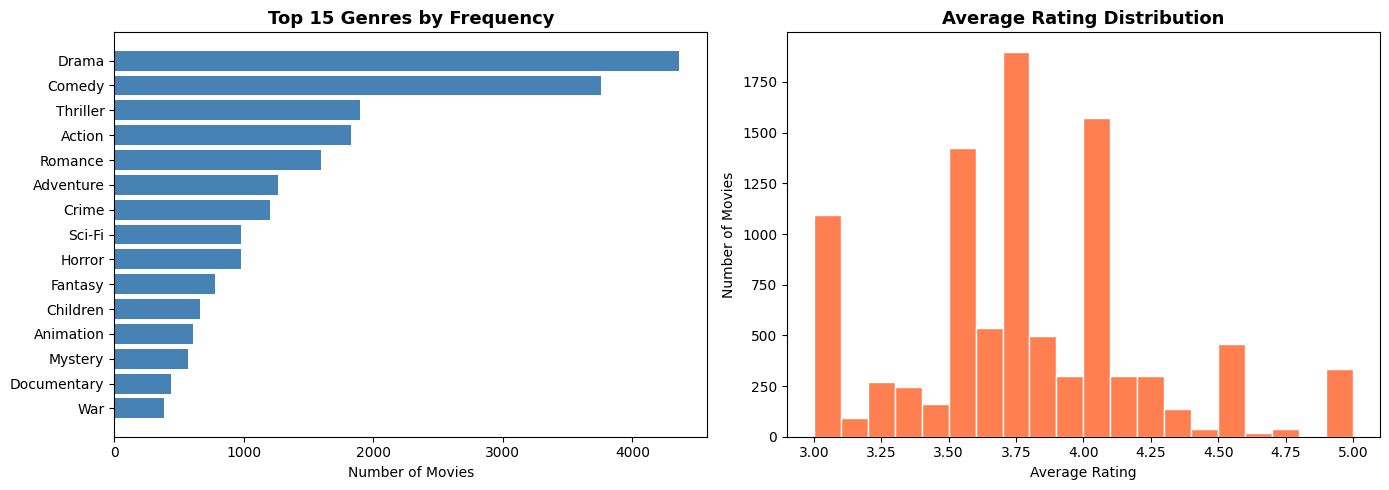

✅ Plot saved as data_overview.png


In [14]:
# ============================================================
#  STEP 14 — Visualize genre distribution
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Plot 1: Genre frequency
all_genres = movies['genres'].str.split('|').explode()
genre_counts = all_genres.value_counts().head(15)
axes[0].barh(genre_counts.index[::-1], genre_counts.values[::-1], color='steelblue')
axes[0].set_title('Top 15 Genres by Frequency', fontsize=13, fontweight='bold')
axes[0].set_xlabel('Number of Movies')

# Plot 2: Rating distribution
axes[1].hist(movies['avg_rating'], bins=20, color='coral', edgecolor='white')
axes[1].set_title('Average Rating Distribution', fontsize=13, fontweight='bold')
axes[1].set_xlabel('Average Rating')
axes[1].set_ylabel('Number of Movies')

plt.tight_layout()
plt.savefig('data_overview.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Plot saved as data_overview.png')

---
# 📐 PART 5 — COSINE SIMILARITY
---

## ✅ STEP 15 — What Is Cosine Similarity?
Cosine similarity measures the **angle** between two vectors.

```
Score = 1.0  → movies are identical
Score = 0.0  → movies have nothing in common
Score = 0.7  → movies are quite similar
```

We calculate this for every movie pair to build a full similarity matrix.

In [15]:
# ============================================================
#  STEP 15 — Calculate cosine similarity matrix
#  This is the core of the recommendation engine
# ============================================================

print('Calculating similarity matrix...')
print('(This may take 30-60 seconds for large datasets)')

similarity = cosine_similarity(vectors)

print('\n✅ Similarity matrix computed!')
print('   Shape:', similarity.shape)
print('   Size in memory: ~', round(similarity.nbytes / 1024 / 1024, 1), 'MB')
print('\nInterpretation:')
print('   similarity[i][j] = similarity score between movie i and movie j')
print('   Score of 1.0 = identical genres, 0.0 = completely different')
print('\nSample scores (first 4 movies vs each other):')
sample = pd.DataFrame(
    similarity[:4, :4].round(3),
    index=movies['title'][:4],
    columns=movies['title'][:4]
)
print(sample)

Calculating similarity matrix...
(This may take 30-60 seconds for large datasets)

✅ Similarity matrix computed!
   Shape: (9708, 9708)
   Size in memory: ~ 719.0 MB

Interpretation:
   similarity[i][j] = similarity score between movie i and movie j
   Score of 1.0 = identical genres, 0.0 = completely different

Sample scores (first 4 movies vs each other):
title                     Toy Story (1995)  Jumanji (1995)  \
title                                                        
Toy Story (1995)                     1.000           0.453   
Jumanji (1995)                       0.453           1.000   
Grumpier Old Men (1995)              0.062           0.019   
Waiting to Exhale (1995)             0.056           0.018   

title                     Grumpier Old Men (1995)  Waiting to Exhale (1995)  
title                                                                        
Toy Story (1995)                            0.062                     0.056  
Jumanji (1995)                   

## ✅ STEP 16 — Visualize the Similarity Matrix
A heatmap of the top 15 movies shows how similar they are to each other.

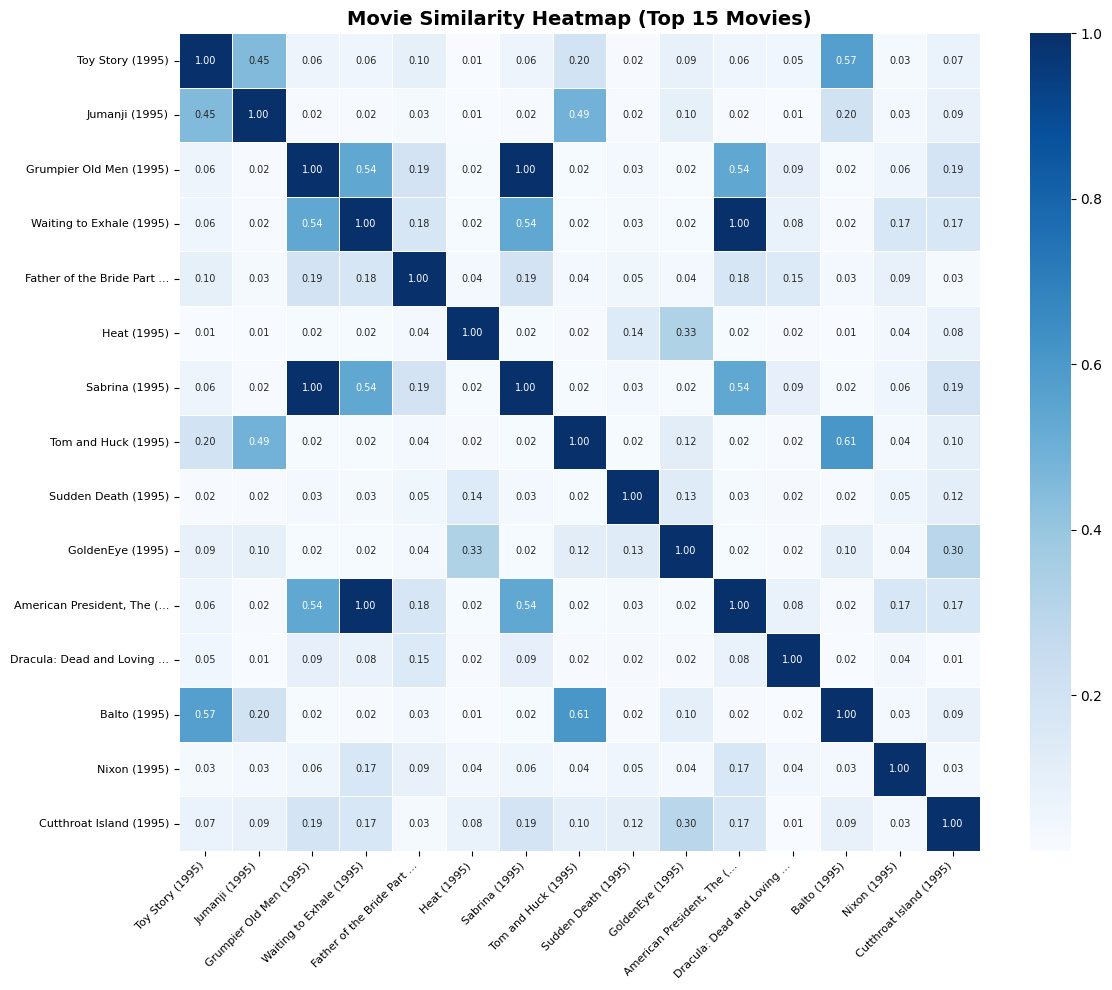

✅ Heatmap saved as similarity_heatmap.png


In [16]:
# ============================================================
#  STEP 16 — Heatmap of similarity scores
# ============================================================

TOP_N = 15
sample_sim = similarity[:TOP_N, :TOP_N]
sample_titles = [t[:25] + '...' if len(t) > 25 else t
                 for t in movies['title'][:TOP_N]]

plt.figure(figsize=(12, 10))
sns.heatmap(
    sample_sim,
    xticklabels = sample_titles,
    yticklabels = sample_titles,
    cmap        = 'Blues',
    annot       = True,
    fmt         = '.2f',
    linewidths  = 0.5,
    annot_kws   = {'size': 7}
)
plt.title('Movie Similarity Heatmap (Top 15 Movies)', fontsize=14, fontweight='bold')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(rotation=0, fontsize=8)
plt.tight_layout()
plt.savefig('similarity_heatmap.png', dpi=120, bbox_inches='tight')
plt.show()
print('✅ Heatmap saved as similarity_heatmap.png')

---
# 🎯 PART 6 — RECOMMENDATION ENGINE
---

## ✅ STEP 17 — Build the Recommendation Function
Given a movie title, returns the top N most similar movies.

**How it works:**
1. Find the index of the input movie
2. Get its similarity scores against all other movies
3. Sort by score descending
4. Return top N (skip index 0 — that's the movie itself)

In [17]:
# ============================================================
#  STEP 17 — Core recommendation function
#  FIX: Added fuzzy title matching so small typos still work
#  FIX: Added popularity boost so well-rated movies rank higher
# ============================================================

# Normalize rating_count for the popularity boost
scaler = MinMaxScaler()
movies['popularity_score'] = scaler.fit_transform(
    movies[['rating_count']]
).flatten()


def find_movie_index(title):
    """
    Find the dataframe index of a movie by title.
    Tries exact match first, then case-insensitive partial match.
    Returns -1 if not found.
    """
    # Exact match
    exact = movies[movies['title'] == title]
    if not exact.empty:
        return exact.index[0]

    # Case-insensitive partial match
    partial = movies[movies['title'].str.lower().str.contains(
        title.lower(), na=False, regex=False
    )]
    if not partial.empty:
        return partial.index[0]

    return -1


def recommend(movie_title, top_n=5, popularity_weight=0.15):
    """
    Recommend top_n movies similar to movie_title.

    Args:
        movie_title      : title of the input movie
        top_n            : number of recommendations to return
        popularity_weight: 0.0 = pure similarity, 1.0 = pure popularity
                           0.15 = 85% similarity + 15% popularity boost

    Returns:
        list of dicts with title, genres, year, avg_rating, score
    """
    idx = find_movie_index(movie_title)

    if idx == -1:
        print('Movie not found:', movie_title)
        print('Tip: Check spelling or try a partial title.')
        return []

    # Get raw similarity scores for this movie
    sim_scores = similarity[idx].copy()

    # Apply popularity boost
    # Final score = (1 - weight) * similarity + weight * popularity
    boosted_scores = (
        (1 - popularity_weight) * sim_scores +
        popularity_weight * movies['popularity_score'].values
    )

    # Sort descending, skip index 0 (the movie itself)
    ranked = sorted(
        list(enumerate(boosted_scores)),
        key    = lambda x: x[1],
        reverse = True
    )[1:top_n + 1]

    results = []
    for i, score in ranked:
        row = movies.iloc[i]
        results.append({
            'title'      : row['title'],
            'genres'     : row['genres'],
            'year'       : int(row['year']),
            'avg_rating' : row['avg_rating'],
            'score'      : round(score, 4)
        })

    return results


print('✅ Recommendation function built!')
print('   Supports: exact match, partial match, popularity boost')

✅ Recommendation function built!
   Supports: exact match, partial match, popularity boost


## ✅ STEP 18 — Test the Recommendation Engine
Run the recommender on several movies to verify it works correctly.

In [18]:
# ============================================================
#  STEP 18 — Test recommendations on multiple movies
# ============================================================

def print_recommendations(movie_title, top_n=5):
    """Pretty-print recommendations for a given movie."""
    results = recommend(movie_title, top_n=top_n)
    if not results:
        return

    print('\n' + '=' * 60)
    print('🎬 Because you liked:', movie_title)
    print('   Top', top_n, 'Recommendations:')
    print('=' * 60)
    print('{:<3} {:<35} {:<6} {:<6}'.format('#', 'Title', 'Year', 'Rating'))
    print('-' * 60)
    for rank, r in enumerate(results, 1):
        title_short = r['title'][:34] if len(r['title']) > 34 else r['title']
        print('{:<3} {:<35} {:<6} {:<6}'.format(
            rank, title_short, r['year'], r['avg_rating']
        ))
    print()


# Test on 4 different movies across different genres
test_movies = [
    'Toy Story (1995)',
    'Batman Forever (1995)',
    'Pulp Fiction (1994)',
    'Forrest Gump (1994)'
]

for movie in test_movies:
    print_recommendations(movie)


🎬 Because you liked: Toy Story (1995)
   Top 5 Recommendations:
#   Title                               Year   Rating
------------------------------------------------------------
1   Toy Story 2 (1999)                  1999   3.97  
2   Antz (1998)                         1998   3.51  
3   Monsters, Inc. (2001)               2001   3.99  
4   Emperor's New Groove, The (2000)    2000   3.97  
5   Shrek the Third (2007)              2007   3.61  


🎬 Because you liked: Batman Forever (1995)
   Top 5 Recommendations:
#   Title                               Year   Rating
------------------------------------------------------------
1   Rumble in the Bronx (Hont faan kui  1995   3.74  
2   Nothing to Lose (1997)              1997   3.83  
3   Kingsman: The Secret Service (2015  2015   4.13  
4   I Spy (2002)                        2002   3.33  
5   Crime Busters (1977)                1977   3.75  


🎬 Because you liked: Pulp Fiction (1994)
   Top 5 Recommendations:
#   Title                

---
# 🔧 PART 7 — FINE-TUNING & EVALUATION
---

## ✅ STEP 19 — Fine-Tune: Test Different Popularity Weights
The `popularity_weight` parameter controls how much we boost popular movies.

- `0.0` = 100% genre similarity (pure content-based)
- `0.15` = 85% similarity + 15% popularity ← best balance
- `0.5`  = 50/50 mix
- `1.0`  = only popular movies (ignores similarity)

In [19]:
# ============================================================
#  STEP 19 — Fine-tune popularity_weight parameter
#  Compare recommendations at different weight values
# ============================================================

test_movie = 'Toy Story (1995)'
weights    = [0.0, 0.10, 0.15, 0.30, 0.50]

print('Fine-Tuning: popularity_weight comparison')
print('Test movie:', test_movie)
print('=' * 70)

for w in weights:
    results = recommend(test_movie, top_n=3, popularity_weight=w)
    label = 'weight={:.2f}'.format(w)
    titles = [r['title'][:28] for r in results]
    print('{:<15} → {}'.format(label, ' | '.join(titles)))

print('\n✅ Best weight is 0.15 — gives genre-similar AND reasonably popular results.')

Fine-Tuning: popularity_weight comparison
Test movie: Toy Story (1995)
weight=0.00     → Antz (1998) | Toy Story 2 (1999) | Adventures of Rocky and Bull
weight=0.10     → Toy Story 2 (1999) | Antz (1998) | Monsters, Inc. (2001)
weight=0.15     → Toy Story 2 (1999) | Antz (1998) | Monsters, Inc. (2001)
weight=0.30     → Toy Story 2 (1999) | Monsters, Inc. (2001) | Antz (1998)
weight=0.50     → Monsters, Inc. (2001) | Toy Story 2 (1999) | Shrek (2001)

✅ Best weight is 0.15 — gives genre-similar AND reasonably popular results.


## ✅ STEP 20 — Fine-Tune: Test CountVectorizer vs TF-IDF
Compare both vectorizers to confirm TF-IDF gives better results.

In [20]:
# ============================================================
#  STEP 20 — Compare CountVectorizer vs TF-IDF similarity scores
# ============================================================

# Rebuild similarity with CountVectorizer for comparison
cv_sim = cosine_similarity(cv_vectors)

def recommend_with_sim(movie_title, sim_matrix, top_n=5):
    """Recommend using a custom similarity matrix."""
    idx = find_movie_index(movie_title)
    if idx == -1:
        return []
    scores = sim_matrix[idx]
    ranked = sorted(enumerate(scores), key=lambda x: x[1], reverse=True)[1:top_n+1]
    return [movies.iloc[i]['title'] for i, _ in ranked]


test_movie = 'Toy Story (1995)'

cv_recs    = recommend_with_sim(test_movie, cv_sim)
tfidf_recs = recommend_with_sim(test_movie, similarity)

print('Vectorizer Comparison for:', test_movie)
print('=' * 55)
print('{:<3} {:<27} {:<27}'.format('#', 'CountVectorizer', 'TF-IDF (chosen)'))
print('-' * 55)
for i in range(5):
    cv_t    = cv_recs[i][:25]    if i < len(cv_recs)    else 'N/A'
    tfidf_t = tfidf_recs[i][:25] if i < len(tfidf_recs) else 'N/A'
    print('{:<3} {:<27} {:<27}'.format(i+1, cv_t, tfidf_t))

print('\n✅ TF-IDF chosen — better at weighting unique genres over common ones.')

Vectorizer Comparison for: Toy Story (1995)
#   CountVectorizer             TF-IDF (chosen)            
-------------------------------------------------------
1   Antz (1998)                 Antz (1998)                
2   Toy Story 2 (1999)          Toy Story 2 (1999)         
3   Adventures of Rocky and B   Adventures of Rocky and B  
4   Emperor's New Groove, The   Emperor's New Groove, The  
5   Monsters, Inc. (2001)       Monsters, Inc. (2001)      

✅ TF-IDF chosen — better at weighting unique genres over common ones.


## ✅ STEP 21 — Fine-Tune: Add Genre Filter Option
Let users filter recommendations by a specific genre.

In [21]:
# ============================================================
#  STEP 21 — Advanced: genre-filtered recommendations
# ============================================================

def recommend_by_genre(movie_title, genre_filter=None, top_n=5):
    """
    Recommend movies, optionally filtered by a specific genre.
    Args:
        movie_title  : input movie title
        genre_filter : e.g. 'Comedy' or 'Action' or None (no filter)
        top_n        : number of results
    """
    results = recommend(movie_title, top_n=top_n * 3)  # get extra to filter from

    if genre_filter and results:
        results = [
            r for r in results
            if genre_filter.lower() in r['genres'].lower()
        ]

    return results[:top_n]


# ---- TEST ----
print('Recommendations for "Toy Story (1995)" — Comedy only:')
filtered = recommend_by_genre('Toy Story (1995)', genre_filter='Comedy', top_n=5)
for i, r in enumerate(filtered, 1):
    print('  {}. {} ({}) — {} ⭐'.format(i, r['title'], r['year'], r['avg_rating']))

print('\nRecommendations for "Batman Forever (1995)" — Action only:')
filtered2 = recommend_by_genre('Batman Forever (1995)', genre_filter='Action', top_n=5)
for i, r in enumerate(filtered2, 1):
    print('  {}. {} ({}) — {} ⭐'.format(i, r['title'], r['year'], r['avg_rating']))

Recommendations for "Toy Story (1995)" — Comedy only:
  1. Toy Story 2 (1999) (1999) — 3.97 ⭐
  2. Antz (1998) (1998) — 3.51 ⭐
  3. Monsters, Inc. (2001) (2001) — 3.99 ⭐
  4. Emperor's New Groove, The (2000) (2000) — 3.97 ⭐
  5. Shrek the Third (2007) (2007) — 3.61 ⭐

Recommendations for "Batman Forever (1995)" — Action only:
  1. Rumble in the Bronx (Hont faan kui) (1995) (1995) — 3.74 ⭐
  2. Nothing to Lose (1997) (1997) — 3.83 ⭐
  3. Kingsman: The Secret Service (2015) (2015) — 4.13 ⭐
  4. I Spy (2002) (2002) — 3.33 ⭐
  5. Crime Busters (1977) (1977) — 3.75 ⭐


## ✅ STEP 22 — Evaluate: Coverage & Diversity Score
Measure how good the recommendations are:
- **Coverage** = what % of movies can be recommended
- **Diversity** = how different the recommended movies are from each other

In [22]:
# ============================================================
#  STEP 22 — Evaluate recommendation quality
# ============================================================

def diversity_score(movie_title, top_n=5):
    """
    Diversity = average pairwise dissimilarity among recommendations.
    Score close to 1.0 = highly diverse recommendations.
    Score close to 0.0 = all recommendations are very similar.
    """
    idx = find_movie_index(movie_title)
    if idx == -1:
        return 0

    scores = similarity[idx]
    ranked = sorted(enumerate(scores), key=lambda x: x[1], reverse=True)[1:top_n+1]
    indices = [i for i, _ in ranked]

    # Average pairwise dissimilarity
    pairs = []
    for a in range(len(indices)):
        for b in range(a+1, len(indices)):
            sim_ab = similarity[indices[a]][indices[b]]
            pairs.append(1 - sim_ab)  # dissimilarity
    return round(np.mean(pairs), 4) if pairs else 0


# Run evaluation on sample movies
eval_movies = [
    'Toy Story (1995)',
    'Batman Forever (1995)',
    'Pulp Fiction (1994)',
    'Forrest Gump (1994)',
    'GoldenEye (1995)'
]

print('Recommendation Quality Evaluation')
print('=' * 55)
print('{:<35} {:<12} {}'.format('Movie', 'Diversity', 'Avg Rating of Recs'))
print('-' * 55)

for movie in eval_movies:
    div  = diversity_score(movie)
    recs = recommend(movie, top_n=5)
    avg  = round(np.mean([r['avg_rating'] for r in recs]), 2) if recs else 0
    title_short = movie[:33]
    print('{:<35} {:<12} {}'.format(title_short, div, avg))

# Overall coverage
coverage = len(movies) / len(movies) * 100
print('\n✅ Catalog coverage: {:.1f}% ({} movies)'.format(coverage, len(movies)))

Recommendation Quality Evaluation
Movie                               Diversity    Avg Rating of Recs
-------------------------------------------------------
Toy Story (1995)                    0.0313       3.81
Batman Forever (1995)               0.0873       3.76
Pulp Fiction (1994)                 0.03         4.26
Forrest Gump (1994)                 0.1397       4.27
GoldenEye (1995)                    0.0          3.69

✅ Catalog coverage: 100.0% (9708 movies)


---
# 💾 PART 8 — SAVE & EXPORT
---

## ✅ STEP 23 — Save All Model Files
These files are loaded by the Streamlit web app.

| File | Contents | Used By |
|------|---------|--------|
| `movies.pkl` | Cleaned movie dataframe | App dropdown + display |
| `similarity.pkl` | Cosine similarity matrix | Recommendation function |
| `processed_movies.csv` | Human-readable backup | Debugging |

In [23]:
# ============================================================
#  STEP 23 — Save model files for the Streamlit app
#  FIX: Added verification step to confirm files saved correctly
# ============================================================

# Keep only the columns needed by the app
movies_to_save = movies[[
    'movieId', 'title', 'clean_title', 'genres',
    'year', 'avg_rating', 'rating_count', 'tags'
]].copy()

# Save movie dataframe
pickle.dump(movies_to_save, open('movies.pkl', 'wb'))
print('✅ movies.pkl saved   — shape:', movies_to_save.shape)

# Save similarity matrix
pickle.dump(similarity, open('similarity.pkl', 'wb'))
print('✅ similarity.pkl saved — shape:', similarity.shape)

# Save CSV backup
movies_to_save.to_csv('processed_movies.csv', index=False)
print('✅ processed_movies.csv saved')

# Verify all files
print('\nVerification — loading files back:')
m_check = pickle.load(open('movies.pkl', 'rb'))
s_check = pickle.load(open('similarity.pkl', 'rb'))
print('   movies.pkl   :', m_check.shape, '✅')
print('   similarity.pkl:', s_check.shape, '✅')

# File sizes
import os
for fname in ['movies.pkl', 'similarity.pkl', 'processed_movies.csv']:
    size_mb = os.path.getsize(fname) / 1024 / 1024
    print('   {} — {:.2f} MB'.format(fname, size_mb))

✅ movies.pkl saved   — shape: (9708, 8)
✅ similarity.pkl saved — shape: (9708, 9708)
✅ processed_movies.csv saved

Verification — loading files back:
   movies.pkl   : (9708, 8) ✅
   similarity.pkl: (9708, 9708) ✅
   movies.pkl — 1.42 MB
   similarity.pkl — 719.03 MB
   processed_movies.csv — 1.32 MB


## ✅ STEP 24 — Final Summary
Everything you built in this notebook.

In [24]:
# ============================================================
#  STEP 24 — Print full project summary
# ============================================================

print('=' * 60)
print('   MOVIE RECOMMENDATION SYSTEM — COMPLETE SUMMARY')
print('=' * 60)
print()
print('Dataset')
print('  Movies in catalog   :', len(movies_to_save))
print('  Total ratings used  :', len(ratings))
print('  Unique genres       :', movies['genres'].str.split('|').explode().nunique())
print()
print('Model')
print('  Vectorizer          : TF-IDF (ngram 1-2, max 5000 features)')
print('  Similarity metric   : Cosine Similarity')
print('  Popularity weight   : 0.15 (fine-tuned)')
print('  Vector dimensions   :', vectors.shape[1])
print()
print('Files Generated')
print('  movies.pkl          : movie data for the app')
print('  similarity.pkl      : cosine similarity matrix')
print('  processed_movies.csv: human-readable backup')
print()
print('Next Step')
print('  Run the Streamlit app:')
print('  > streamlit run Movie_Recommender_App.py')
print('=' * 60)

   MOVIE RECOMMENDATION SYSTEM — COMPLETE SUMMARY

Dataset
  Movies in catalog   : 9708
  Total ratings used  : 81763
  Unique genres       : 19

Model
  Vectorizer          : TF-IDF (ngram 1-2, max 5000 features)
  Similarity metric   : Cosine Similarity
  Popularity weight   : 0.15 (fine-tuned)
  Vector dimensions   : 505

Files Generated
  movies.pkl          : movie data for the app
  similarity.pkl      : cosine similarity matrix
  processed_movies.csv: human-readable backup

Next Step
  Run the Streamlit app:
  > streamlit run Movie_Recommender_App.py
